
Model: Logistic Regression
uncalibrated | train_acc=1.0000 | time=1.24s
  K0 values found: 20


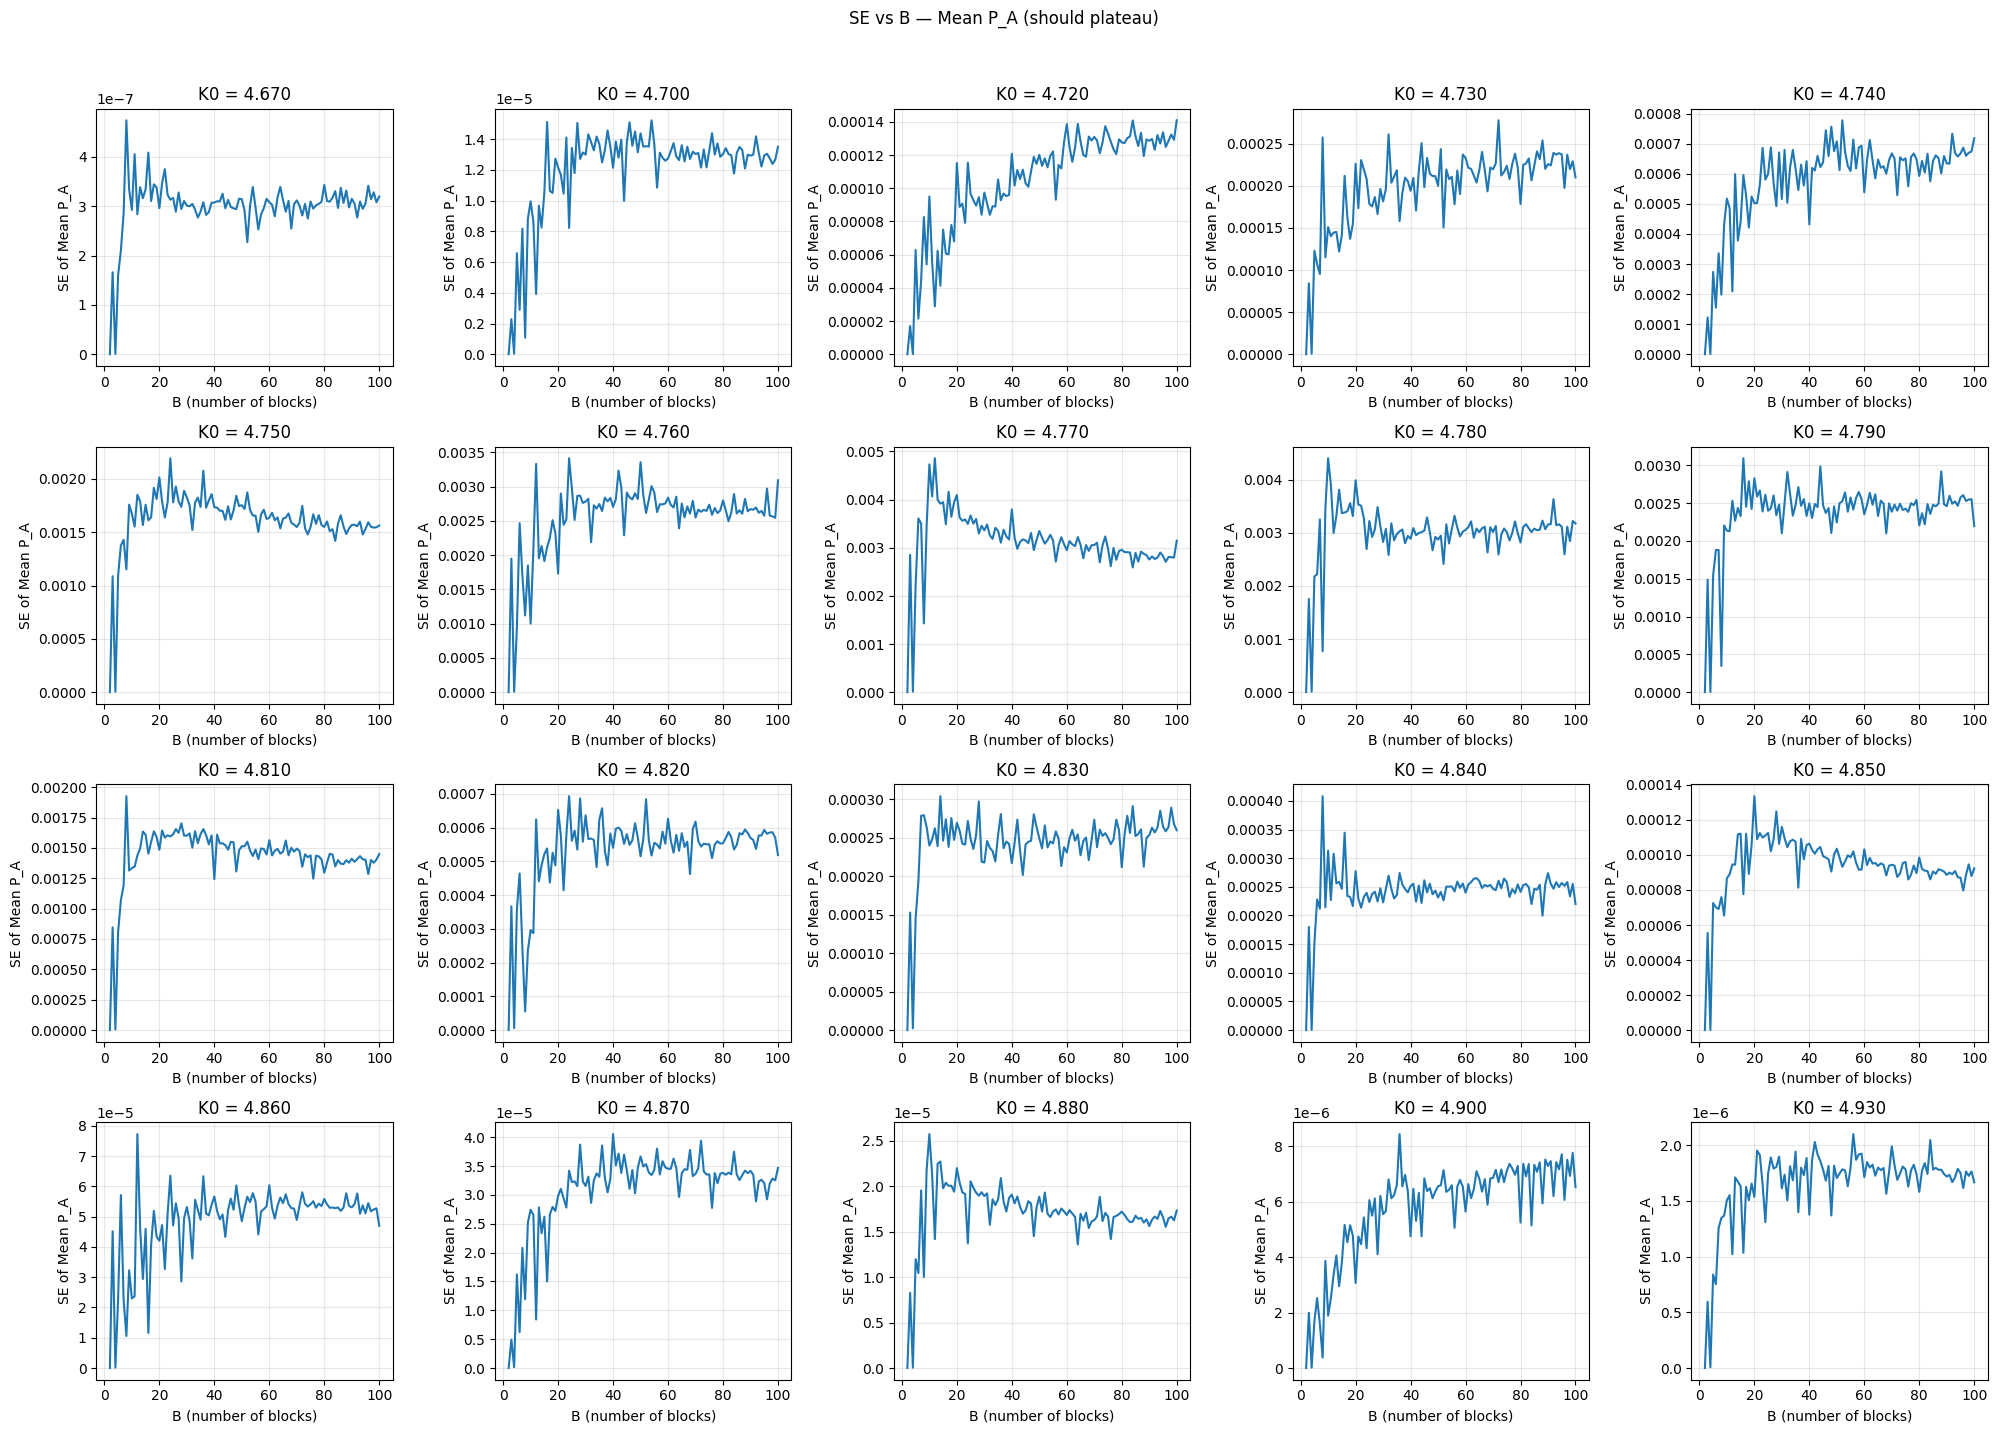

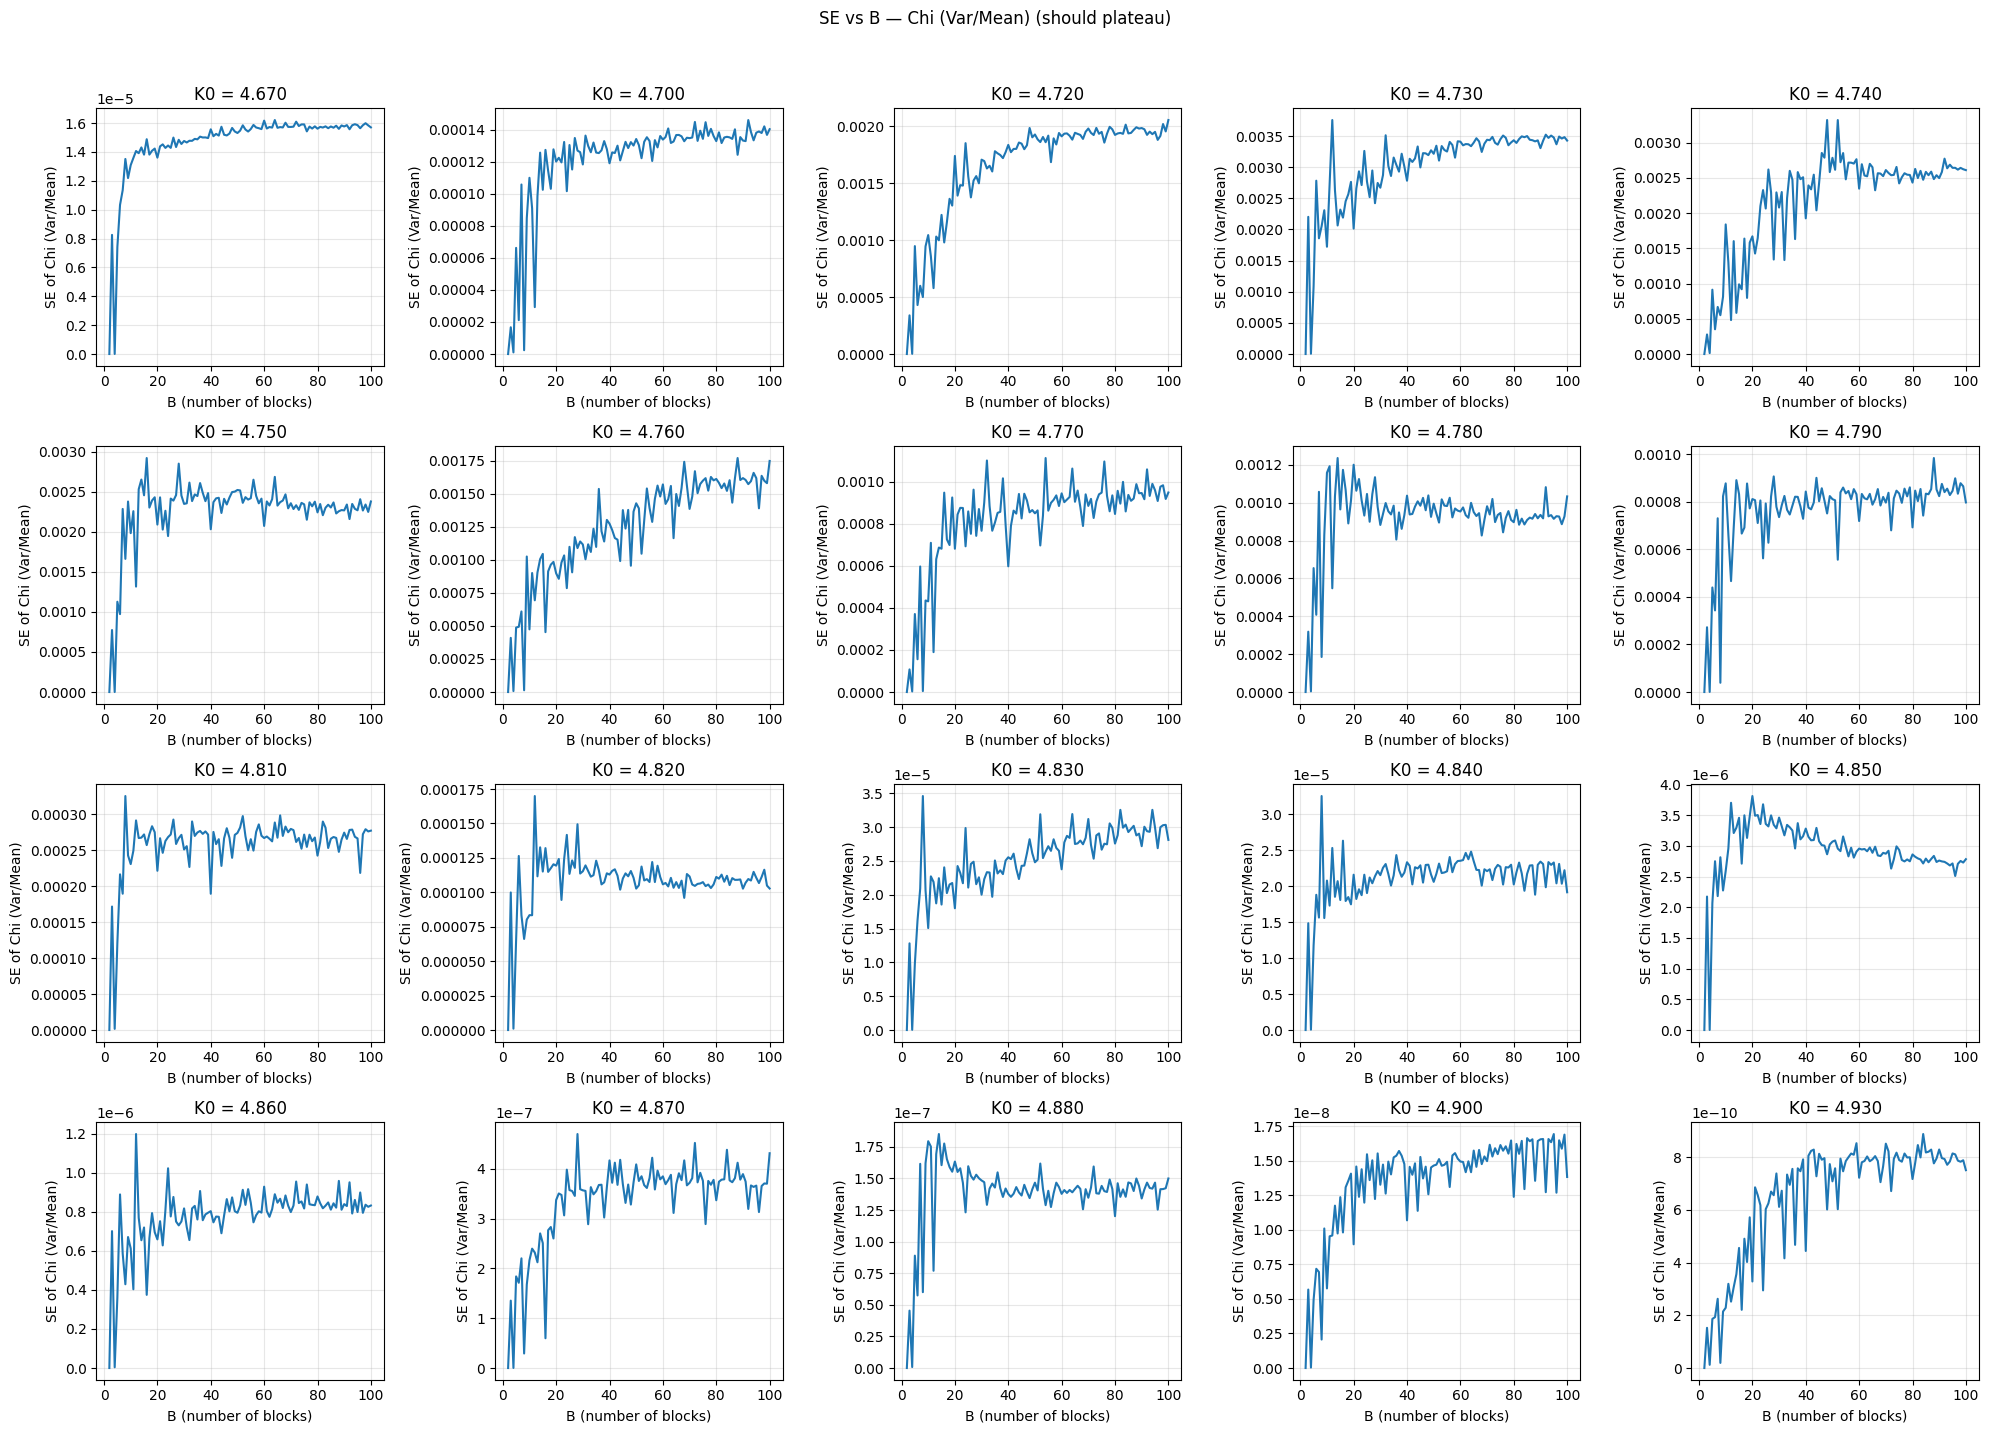

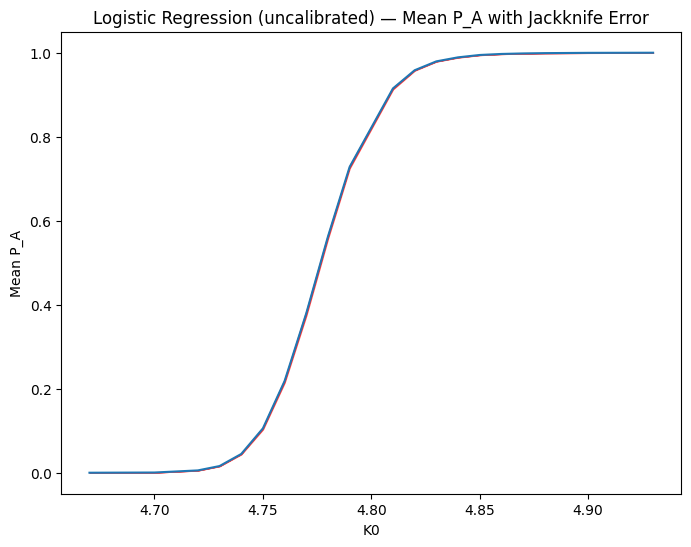

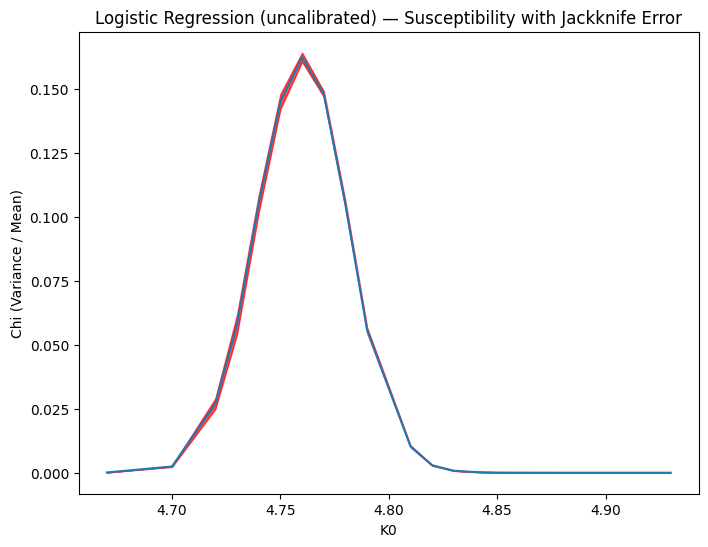

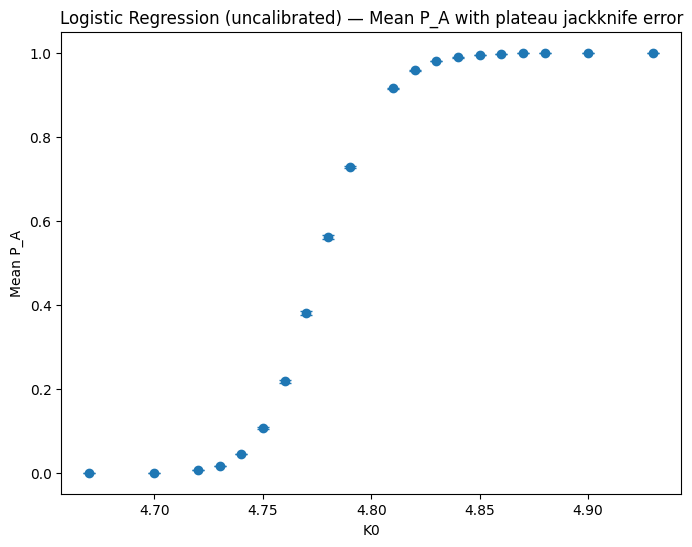

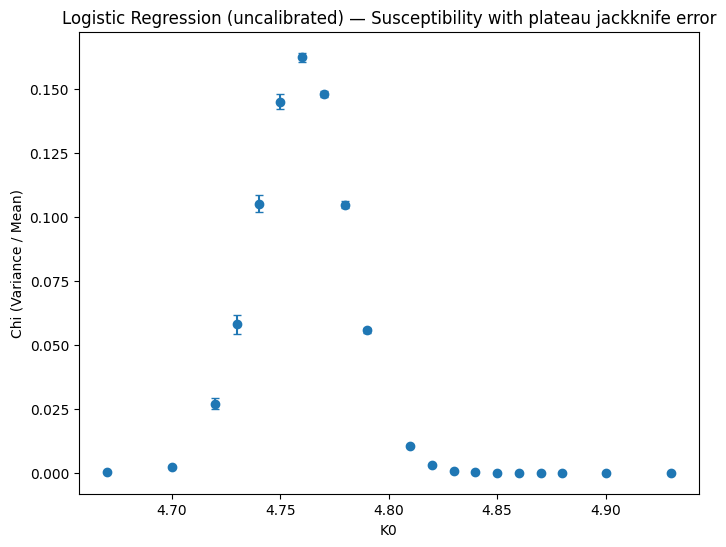

In [8]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

train = np.load("../data/c_a/processed/dataset_train_shortened.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]

full = np.load("../data/c_a/processed/dataset_full.npz", allow_pickle=True)
X_full  = full["X"]
K0_full = full["K0"]


def build_model(base_model, calibrated=False):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", base_model)
    ])
    if not calibrated:
        return pipe
    if isinstance(base_model, LogisticRegression):
        return pipe
    return CalibratedClassifierCV(pipe, method="sigmoid", cv=3)


def run_supervised_pipeline(model, X_train, y_train, X_full):
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)

    if hasattr(model, "predict_proba"):
        P_A = model.predict_proba(X_full)[:, 1]
    else:
        scores = model.decision_function(X_full)
        P_A = 1.0 / (1.0 + np.exp(-scores))

    return train_score, P_A


def stat_mean(x):
    return np.mean(x)


def stat_susceptibility(x):
    # Mathematica: Variance[...] / Mean[...] where Variance uses ddof=1
    return np.var(x, ddof=1) / np.mean(x)


def block_jackknife(data, stat_func, B):
    """
    Block jackknife with B blocks.

    Matches Mathematica tutor code exactly:
      - truncate data to m*B elements
      - reshape into B blocks of size m
      - compute full estimator EX on truncated data
      - leave one block out at a time, compute stat on remaining B-1 blocks
      - bias = (B-1) * (mean(dats) - EX)          [jack.pdf eq 3.2.1]
      - theta_jack = EX - bias                      [bias-corrected estimate]
      - var = Variance(dats) * (B-1)^2 / B         [Mathematica Variance = ddof=1]
      - se = sqrt(var)

    Returns: (theta_hat, theta_jack, se) for this specific B,
             or None if block size < 1.
    """
    n = len(data)
    m = n // B  # block size (integer division, matches Mathematica Quotient)

    if m < 1:
        return None

    # Truncate to m*B  (matches: data[[1 ;; Quotient[len,B]*B]])
    data = data[:m * B]

    # Reshape into B blocks  (matches: Table[data[[m*i+1 ;; m*(i+1)]], {i,0,B-1}])
    blocks = data.reshape(B, m)

    # Full estimator on truncated data  (matches: EX = stat_func(data))
    theta_hat = stat_func(data)

    # Leave-one-block-out replicates
    # Matches: rands = Table[DeleteCases[Range[B], i], {i, B}]
    #          dats  = Table[stat(Flatten[blocks[rands[i]]]), {i, B}]
    dats = np.array([
        stat_func(np.concatenate([blocks[:i], blocks[i+1:]]).ravel())
        for i in range(B)
    ])

    # Bias: (B-1) * (mean(dats) - EX)  [jack.pdf 3.2.1, Mathematica bias line]
    bias = (B - 1) * (np.mean(dats) - theta_hat)

    # Bias-corrected estimator: EXUn = EX - bias
    theta_jack = theta_hat - bias

    # Variance of replications using ddof=1  (Mathematica Variance = sample variance)
    # var = Variance[dats] * (B-1)^2 / B
    var = np.var(dats, ddof=1) * (B - 1)**2 / B
    se = np.sqrt(var)

    return theta_hat, theta_jack, se


# =============================================================================
# JACKKNIFE OVER K0 — returns FULL TABLE for every B, matching Mathematica output
# =============================================================================

def jackknife_over_K(P_A, K0, stat_func, B_range=range(2, 101)):
    """
    For each unique K0 value, run block_jackknife for every B in B_range.

    Returns a dict:  {k: DataFrame with columns [B, theta_hat, theta_jack, se]}

    This matches the Mathematica Table[..., {ildanych, 2, 100, 1}] output exactly.
    You can then inspect SE vs B plots to find the plateau, rather than
    artificially picking the maximum SE.
    """
    df_input = pd.DataFrame({"K0": K0, "P_A": P_A})
    results = {}

    for k, group in df_input.groupby("K0"):
        data = group["P_A"].values

        if len(data) < 2:
            continue

        rows = []
        for B in B_range:
            out = block_jackknife(data, stat_func, B)
            if out is None:
                continue
            theta_hat, theta_jack, se = out
            rows.append({
                "B":          B,
                "theta_hat":  theta_hat,   # EX  in Mathematica
                "theta_jack": theta_jack,  # EXUn in Mathematica
                "se":         se,          # Smse in Mathematica
            })

        results[k] = pd.DataFrame(rows)

    return results


def summarise_jackknife(results_dict):
    """
    Dla każdego K0 wybierz wiersz z największym SE (po wszystkich B),
    i zwróć odpowiadające mu theta_jack i se.

    Returns: K_vals, theta_arr, se_arr  (all numpy arrays, sorted by K)
    """
    K_vals, theta_arr, se_arr = [], [], []

    for k in sorted(results_dict.keys()):
        df = results_dict[k]
        if df.empty:
            continue

        row = df.loc[df["se"].idxmax()]

        K_vals.append(k)
        theta_arr.append(row["theta_jack"])
        se_arr.append(row["se"])

    return np.array(K_vals), np.array(theta_arr), np.array(se_arr)


def plot_se_vs_B(results_dict, stat_label, target_Ks=None, ncols=5):
    """
    Reproduce the Mathematica diagnostic: plot SE vs B for each K value.
    Use this to verify that the SE has plateaued before trusting the summary.
    All K values are shown, arranged in a grid with ncols columns.
    """
    ks = sorted(results_dict.keys())
    if target_Ks is not None:
        ks = [k for k in ks if k in target_Ks]

    n = len(ks)
    if n == 0:
        return

    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), squeeze=False)

    for idx, k in enumerate(ks):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]
        df = results_dict[k]
        ax.plot(df["B"], df["se"], lw=1.5)
        ax.set_title(f"K0 = {k:.3f}")
        ax.set_xlabel("B (number of blocks)")
        ax.set_ylabel(f"SE of {stat_label}")
        ax.grid(True, alpha=0.3)

    # Hide any leftover empty subplots
    for idx in range(n, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    fig.suptitle(f"SE vs B — {stat_label} (should plateau)", y=1.02)
    plt.tight_layout()


# =============================================================================
# MAIN
# =============================================================================

models = {
    "Logistic Regression": LogisticRegression(),
}

curves = {}

for name, base_model in models.items():
    print(f"\n{'='*50}\nModel: {name}\n{'='*50}")
    curves[name] = {}

    for calibrated in [False]:
        label = "calibrated" if calibrated else "uncalibrated"
        model = build_model(base_model, calibrated=calibrated)

        t0 = time.perf_counter()
        train_score, P_A = run_supervised_pipeline(model, X_train, y_train, X_full)
        elapsed = time.perf_counter() - t0

        print(f"{label:12s} | train_acc={train_score:.4f} | time={elapsed:.2f}s")

        # Full B-tables, one DataFrame per K0 value — mirrors Mathematica output
        mean_results = jackknife_over_K(P_A, K0_full, stat_mean)
        chi_results  = jackknife_over_K(P_A, K0_full, stat_susceptibility)

        print(f"  K0 values found: {len(mean_results)}")

        # Summarise using plateau average (physically correct)
        K_mean, mean_jack, mean_se = summarise_jackknife(mean_results)
        K_chi,  chi_jack,  chi_se  = summarise_jackknife(chi_results)

        curves[name][label] = {
            "K":      K_mean,
            "mean":   mean_jack,
            "mean_se": mean_se,
            "chi":    chi_jack,
            "chi_se": chi_se,
            # Keep raw tables for diagnostics
            "_mean_results": mean_results,
            "_chi_results":  chi_results,
        }

# =============================================================================
# DIAGNOSTIC: SE vs B plots (mirrors the Mathematica table inspection)
# =============================================================================

for name in curves:
    for label in curves[name]:
        data = curves[name][label]
        plot_se_vs_B(data["_mean_results"], stat_label="Mean P_A" )
        plot_se_vs_B(data["_chi_results"],  stat_label="Chi (Var/Mean)")

# =============================================================================
# MAIN PLOTS — fill_between style
# =============================================================================

for name in curves:
    for label in curves[name]:
        data = curves[name][label]
        K = data["K"]

        # Mean P_A
        plt.figure(figsize=(8, 6))
        plt.title(f"{name} ({label}) — Mean P_A with Jackknife Error")
        plt.plot(K, data["mean"])
        plt.fill_between(
            K,
            data["mean"] - data["mean_se"],
            data["mean"] + data["mean_se"],
            alpha=0.7,
            color="red",
        )
        plt.xlabel("K0")
        plt.ylabel("Mean P_A")

        # Susceptibility
        plt.figure(figsize=(8, 6))
        plt.title(f"{name} ({label}) — Susceptibility with Jackknife Error")
        plt.plot(K, data["chi"])
        plt.fill_between(
            K,
            data["chi"] - data["chi_se"],
            data["chi"] + data["chi_se"],
            alpha=0.7,
            color="red",
        )
        plt.xlabel("K0")
        plt.ylabel("Chi (Variance / Mean)")

# =============================================================================
# ERRORBAR PLOTS
# =============================================================================

for name in curves:
    for label in curves[name]:
        data = curves[name][label]
        K = data["K"]

        plt.figure(figsize=(8, 6))
        plt.errorbar(K, data["mean"], yerr=data["mean_se"], fmt='o', capsize=4)
        plt.xlabel("K0")
        plt.ylabel("Mean P_A")
        plt.title(f"{name} ({label}) — Mean P_A with plateau jackknife error")

        plt.figure(figsize=(8, 6))
        plt.errorbar(K, data["chi"], yerr=data["chi_se"], fmt='o', capsize=3)
        plt.xlabel("K0")
        plt.ylabel("Chi (Variance / Mean)")
        plt.title(f"{name} ({label}) — Susceptibility with plateau jackknife error")

plt.show()

In [5]:
import os
os.makedirs("plots", exist_ok=True)
def plot_se_vs_B(results_dict, stat_label, target_Ks=None, ncols=5, save_path=None):
    ks = sorted(results_dict.keys())
    if target_Ks is not None:
        ks = [k for k in ks if k in target_Ks]

    n = len(ks)
    if n == 0:
        return

    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), squeeze=False)

    for idx, k in enumerate(ks):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]
        df = results_dict[k]
        ax.plot(df["B"], df["se"], lw=1.5)
        ax.set_title(f"K0 = {k:.3f}")
        ax.set_xlabel("B (number of blocks)")
        ax.set_ylabel(f"SE of {stat_label}")
        ax.grid(True, alpha=0.3)

    for idx in range(n, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    fig.suptitle(f"SE vs B — {stat_label} (should plateau)", y=1.02)
    plt.tight_layout()

    # ✅ THIS is the only new part
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig

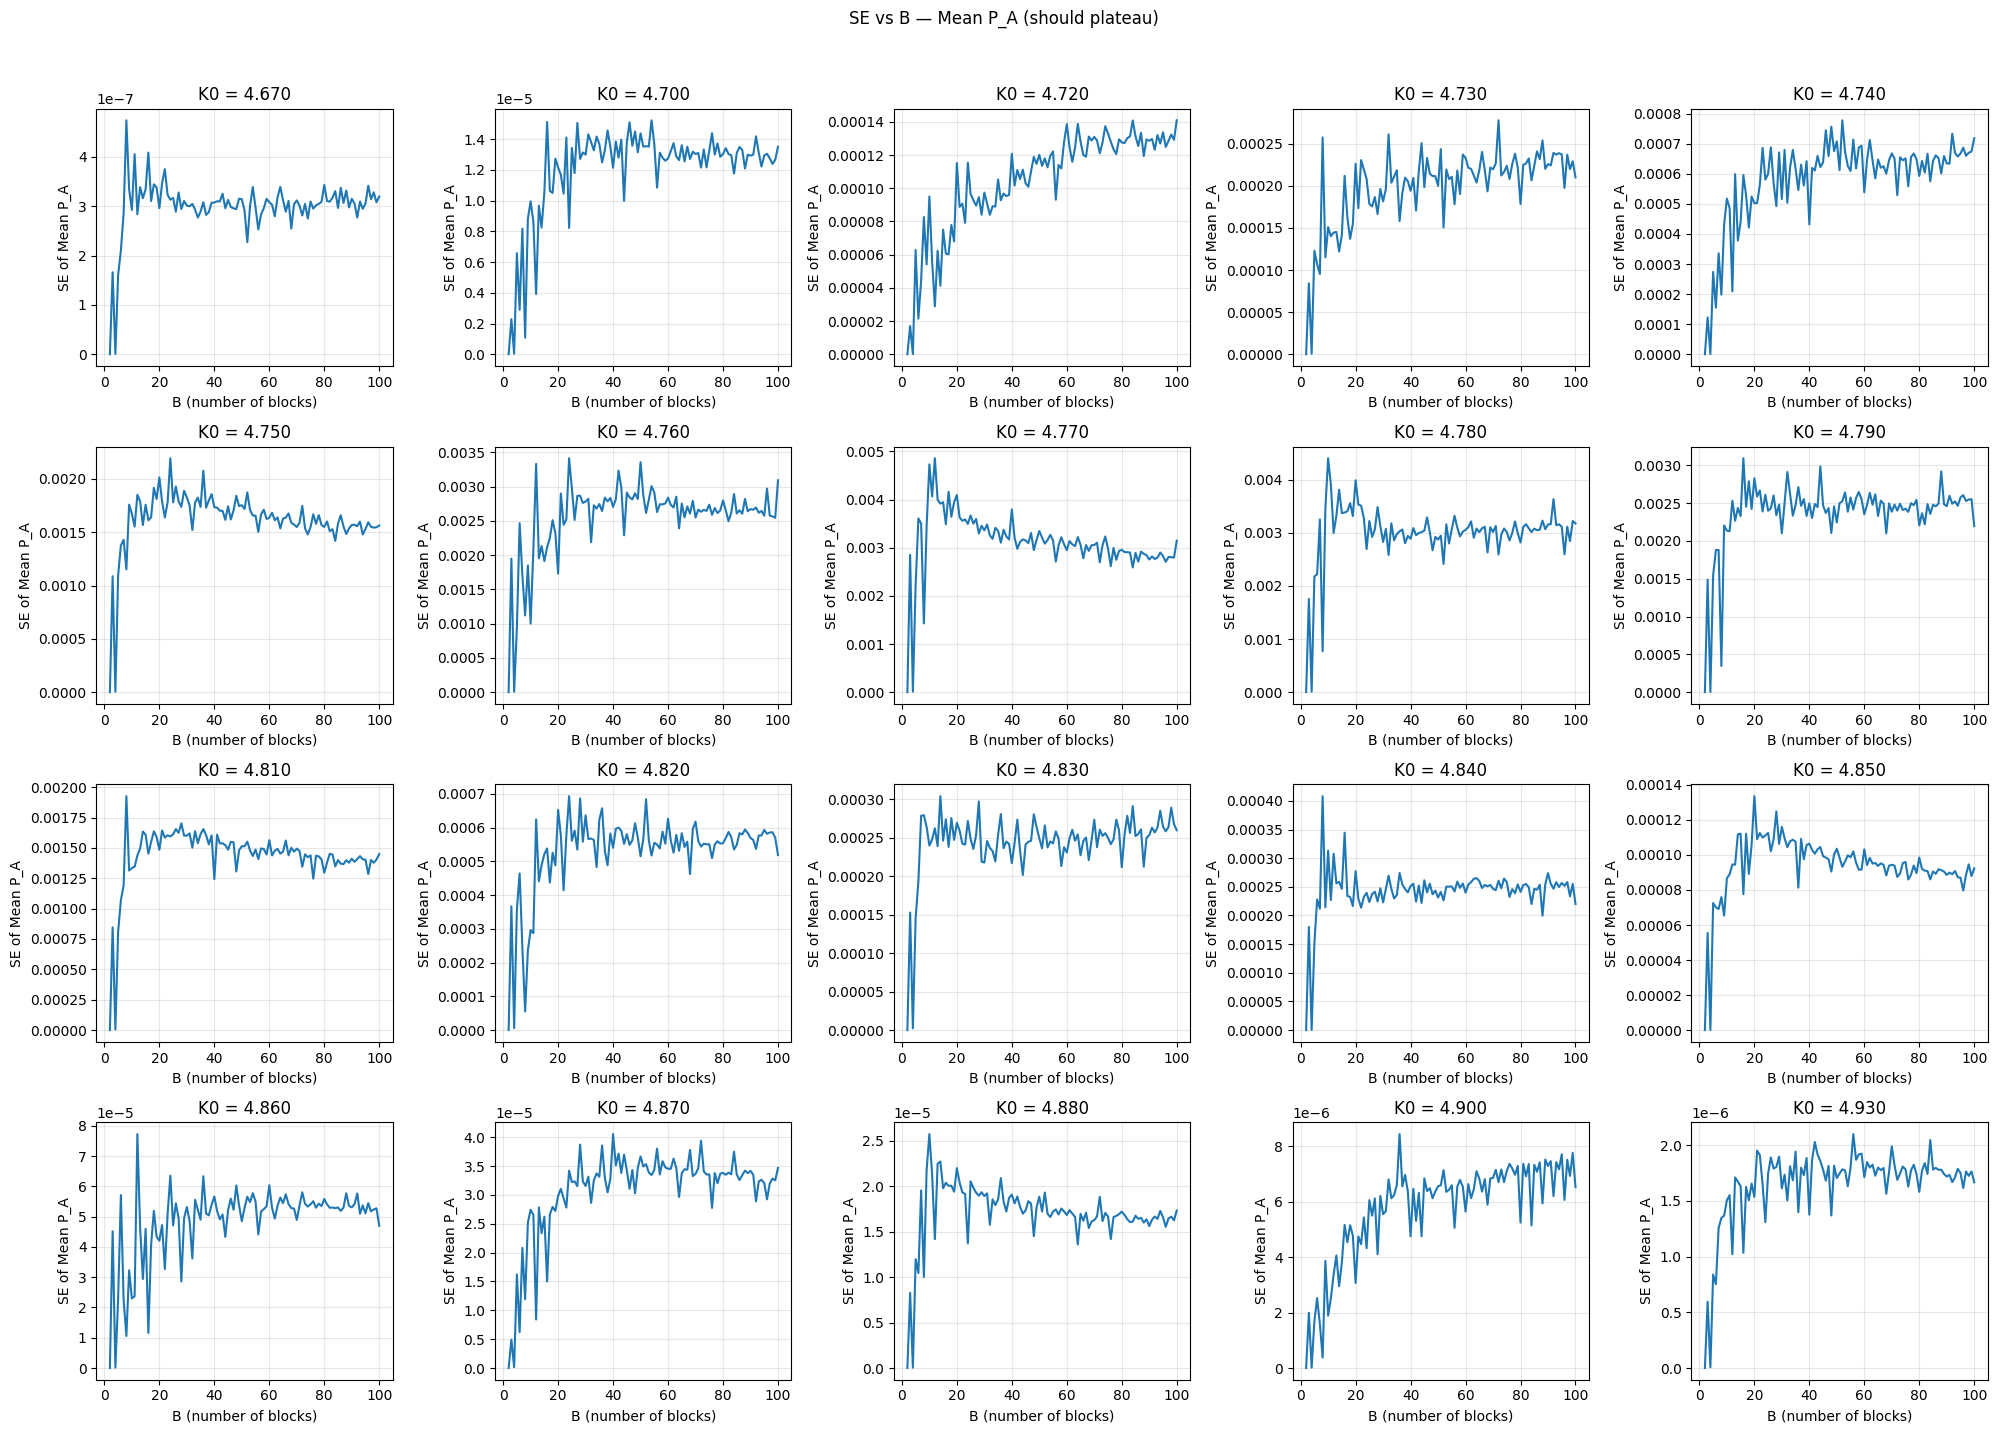

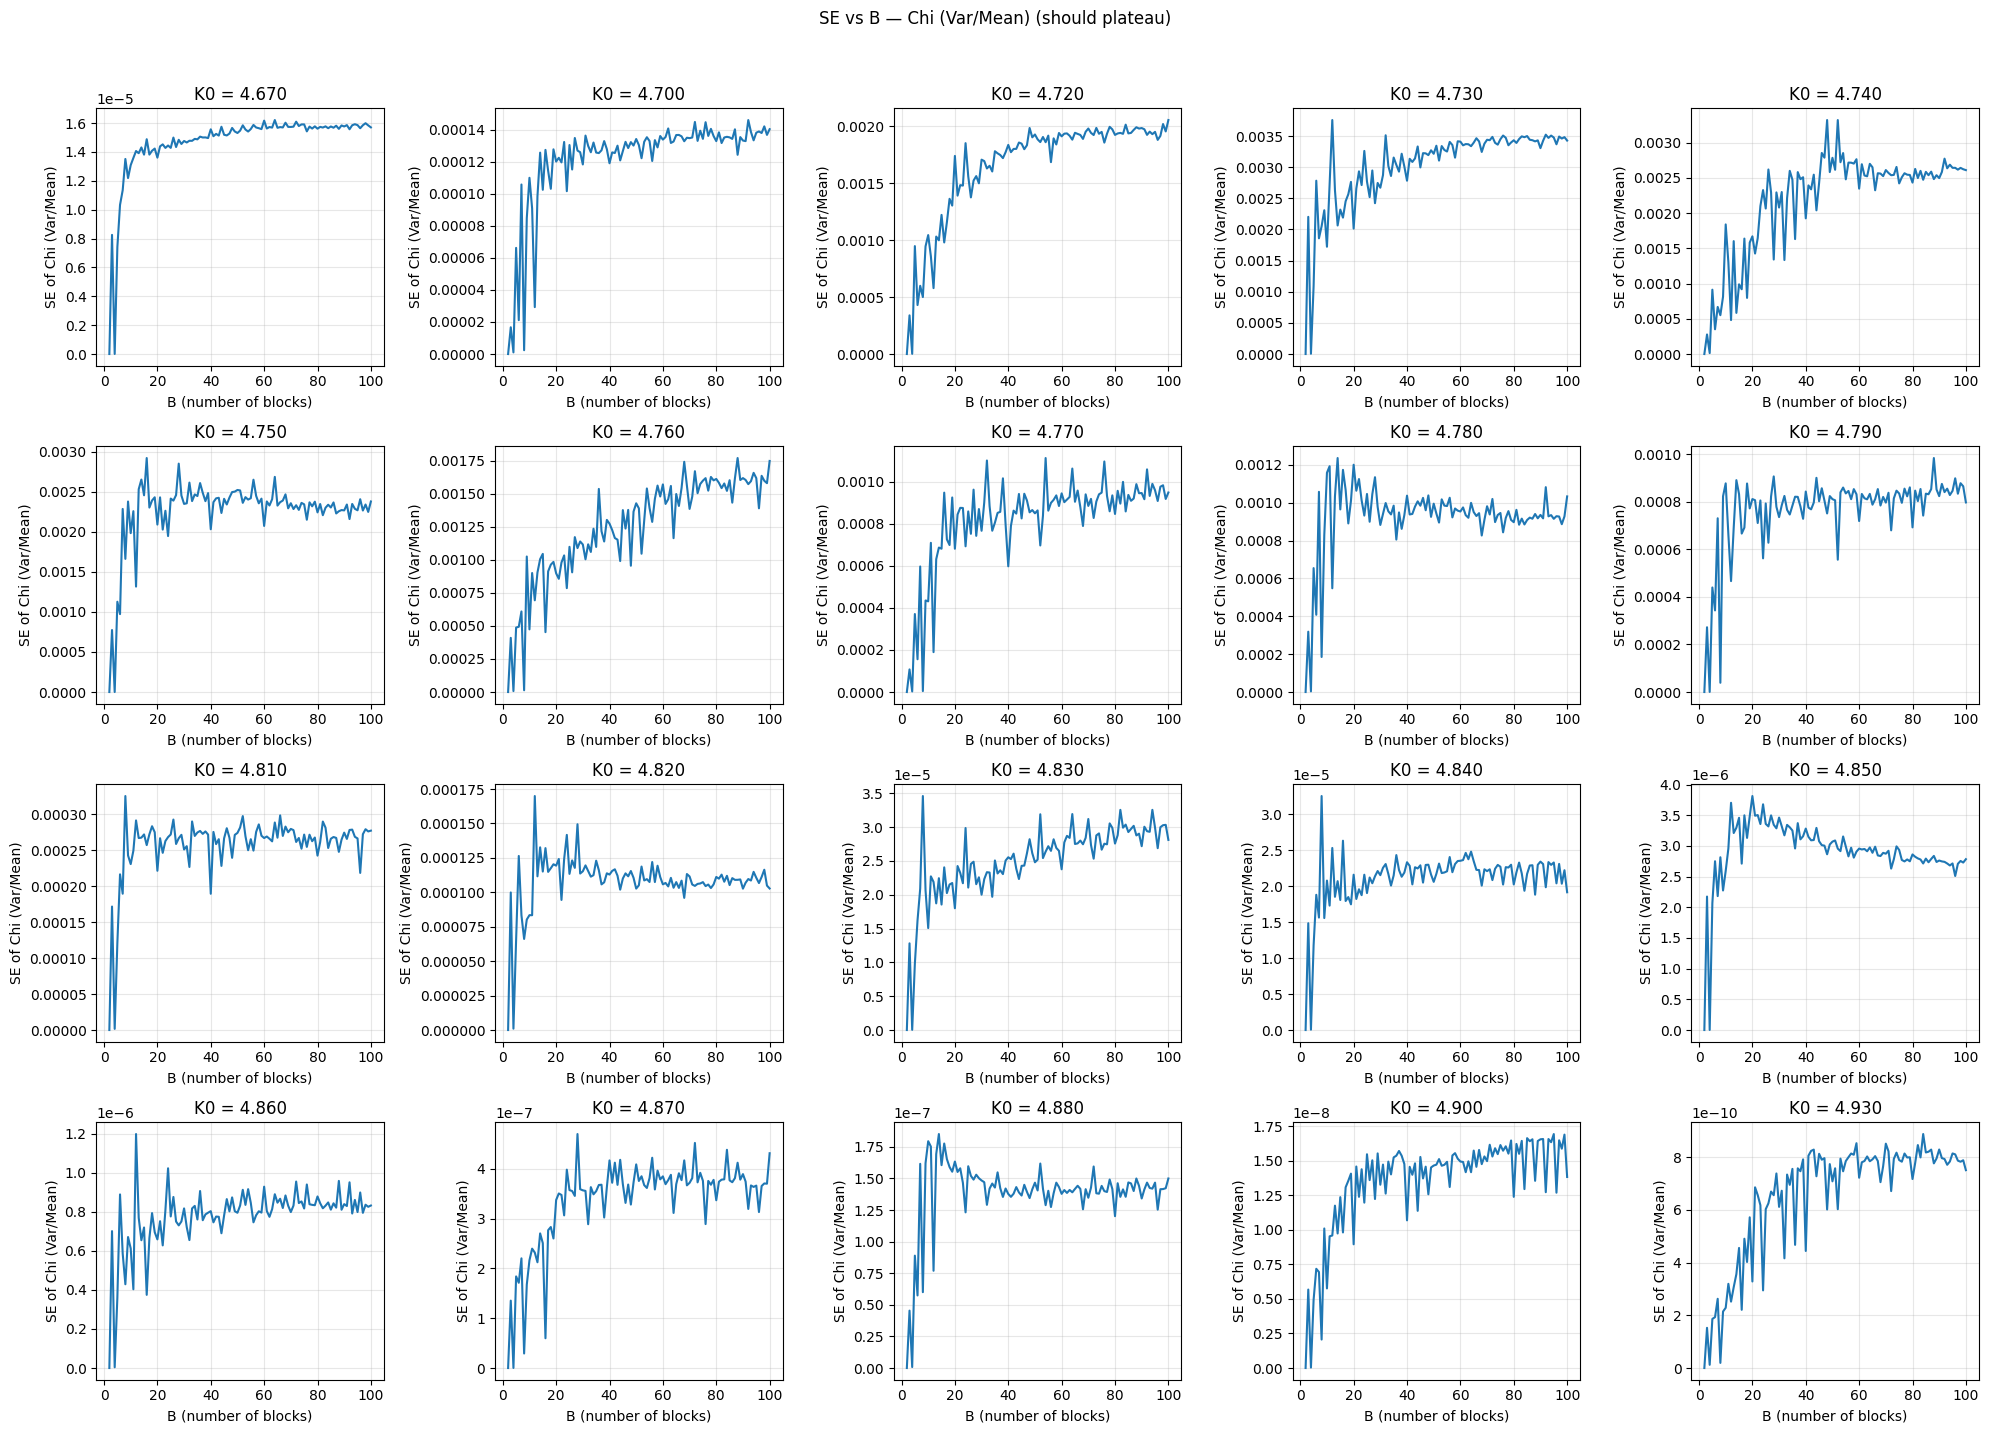

In [6]:
for name in curves:
    for label in curves[name]:
        data = curves[name][label]

        plot_se_vs_B(
            data["_mean_results"],
            stat_label="Mean P_A",
            save_path=f"plots/{name}_{label}_mean_se_vs_B.png"
        )

        plot_se_vs_B(
            data["_chi_results"],
            stat_label="Chi (Var/Mean)",
            save_path=f"plots/{name}_{label}_chi_se_vs_B.png"
        )